In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("vishardmehta/faang-stock-market-data-with-technical-indicators")

Using Colab cache for faster access to the 'faang-stock-market-data-with-technical-indicators' dataset.


In [ ]:
# 2. List files to see what's inside
print("Files in directory:", os.listdir(path))

Files in directory: ['faang_stock_prices.csv']


In [ ]:
import pandas as pd
import numpy as np

# Define the filename found in your directory list
file_name = "faang_stock_prices.csv"

# Join the path to the specific file
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             14964 non-null  object 
 1   Ticker           14964 non-null  object 
 2   Open             14964 non-null  float64
 3   High             14964 non-null  float64
 4   Low              14964 non-null  float64
 5   Close            14964 non-null  float64
 6   Volume           14964 non-null  int64  
 7   SMA_7            14964 non-null  float64
 8   SMA_21           14964 non-null  float64
 9   EMA_12           14964 non-null  float64
 10  EMA_26           14964 non-null  float64
 11  RSI_14           14964 non-null  float64
 12  MACD             14964 non-null  float64
 13  MACD_Signal      14964 non-null  float64
 14  Bollinger_Upper  14964 non-null  float64
 15  Bollinger_Lower  14964 non-null  float64
 16  Daily_Return     14964 non-null  float64
 17  Volatility_7

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

target_col = 'Daily_Return'
drop_cols = ['Date', 'Ticker', target_col]
num_cols = [col for col in df.columns if col not in drop_cols]

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

pre_transform = ColumnTransformer(
    transformers=[
        ("drop", "drop", drop_cols),
        ("num", numeric_tf, num_cols)
    ],
    remainder='drop'
)

feature_pipeline = Pipeline(steps=[
    ("preprocess", pre_transform)
])

# for target alone
target_scaler = MinMaxScaler()

In [ ]:
def create_sequences(X_data, y_data, sequence_length):
    X_seq, y_seq = [], []

    # Start at index N, looking backwards N steps each time
    for i in range(sequence_length, len(X_data)):
        # Grab N days of history
        X_seq.append(X_data[i - sequence_length : i])
        # Grab the single target value for the day immediately following the sequence
        y_seq.append(y_data[i])

    return np.array(X_seq), np.array(y_seq)

In [ ]:
# 2 weeks data
seq_len = 14
train_dfs, val_dfs, test_dfs = [], [], []

for ticker, group in df.groupby('Ticker'):
    train_end = int(len(group) * 0.70)
    val_end = int(len(group) * 0.85)

    train_dfs.append(group.iloc[:train_end])
    val_dfs.append(group.iloc[train_end:val_end])
    test_dfs.append(group.iloc[val_end:])

all_train_df = pd.concat(train_dfs)
all_val_df = pd.concat(val_dfs)
all_test_df = pd.concat(test_dfs)

# Fit preprocess
feature_pipeline.fit(all_train_df)
target_scaler.fit(all_train_df[[target_col]])

MinMaxScaler()

In [ ]:
X_train_2d = feature_pipeline.transform(all_train_df)
y_train_2d = target_scaler.transform(all_train_df[[target_col]])

X_val_2d = feature_pipeline.transform(all_val_df)
y_val_2d = target_scaler.transform(all_val_df[[target_col]])

X_test_2d = feature_pipeline.transform(all_test_df)
y_test_2d = target_scaler.transform(all_test_df[[target_col]])

# Add temp indices for safe slicing
all_train_df['temp_idx'] = np.arange(len(all_train_df))
all_val_df['temp_idx'] = np.arange(len(all_val_df))
all_test_df['temp_idx'] = np.arange(len(all_test_df))

X_train_seqs, y_train_seqs = [], []
X_val_seqs, y_val_seqs = [], []
X_test_seqs, y_test_seqs = [], []

for ticker in df['Ticker'].unique():
    # Train Sequences
    train_idx = all_train_df[all_train_df['Ticker'] == ticker]['temp_idx'].values
    if len(train_idx) > seq_len:
        X_tr, y_tr = create_sequences(X_train_2d[train_idx], y_train_2d[train_idx], seq_len)
        X_train_seqs.append(X_tr)
        y_train_seqs.append(y_tr)

    # Validation Sequences
    val_idx = all_val_df[all_val_df['Ticker'] == ticker]['temp_idx'].values
    if len(val_idx) > seq_len:
        X_v, y_v = create_sequences(X_val_2d[val_idx], y_val_2d[val_idx], seq_len)
        X_val_seqs.append(X_v)
        y_val_seqs.append(y_v)

    # Test Sequences
    test_idx = all_test_df[all_test_df['Ticker'] == ticker]['temp_idx'].values
    if len(test_idx) > seq_len:
        X_te, y_te = create_sequences(X_test_2d[test_idx], y_test_2d[test_idx], seq_len)
        X_test_seqs.append(X_te)
        y_test_seqs.append(y_te)

# Final Concatenation
X_train_final = np.concatenate(X_train_seqs, axis=0)
y_train_final = np.concatenate(y_train_seqs, axis=0)

X_val_final = np.concatenate(X_val_seqs, axis=0)
y_val_final = np.concatenate(y_val_seqs, axis=0)

X_test_final = np.concatenate(X_test_seqs, axis=0)
y_test_final = np.concatenate(y_test_seqs, axis=0)

In [ ]:
print(X_train_final.shape)
print(y_train_final.shape)
print(X_test_final.shape)
print(y_test_final.shape)

print(X_train_final[0,0])

(10386, 14, 16)
(10386, 1)
(2166, 14, 16)
(2166, 1)
[0.05575491 0.05539292 0.05510222 0.05464595 0.03301546 0.05608453
 0.05685989 0.05643234 0.05748432 0.50839432 0.67809003 0.6954464
 0.05521385 0.05696074 0.14241104 0.05548987]


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

In [ ]:
import torch.nn as nn

class StockRNN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, 512, batch_first=True)
        self.fc = nn.Linear(512, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        # Final FC operates on last seq item
        return self.fc(out[:, -1, :])

In [ ]:
def train(dataloader, model, loss_fn, optimizer, device):
    model.train()

    num_batches = len(dataloader)
    train_loss = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y = y.view(-1, 1)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= num_batches

    return train_loss

def test(dataloader, model, loss_fn, device):
      model.to(device)

      size = len(dataloader.dataset)
      num_batches = len(dataloader)
      test_loss = 0

      model.eval()
      with torch.no_grad():
          for X, y in dataloader:
              X, y = X.to(device), y.to(device)
              y = y.view(-1, 1)

              y_pred = model(X)
              test_loss += loss_fn(y_pred, y).item()

      test_loss /= num_batches

      return test_loss

INIT TRAINING
Epoch 1/100: Train Loss 0.003847 | Val Loss 0.001472
*** New best model found! Val Loss: 0.001472. Saving weights... ***
Epoch 2/100: Train Loss 0.001676 | Val Loss 0.001485
Epoch 3/100: Train Loss 0.001690 | Val Loss 0.001964
Epoch 4/100: Train Loss 0.001607 | Val Loss 0.001211
*** New best model found! Val Loss: 0.001211. Saving weights... ***
Epoch 5/100: Train Loss 0.001561 | Val Loss 0.001182
*** New best model found! Val Loss: 0.001182. Saving weights... ***
Epoch 6/100: Train Loss 0.001542 | Val Loss 0.001137
*** New best model found! Val Loss: 0.001137. Saving weights... ***
Epoch 7/100: Train Loss 0.001402 | Val Loss 0.001134
*** New best model found! Val Loss: 0.001134. Saving weights... ***
Epoch 8/100: Train Loss 0.001320 | Val Loss 0.001221
Epoch 9/100: Train Loss 0.001272 | Val Loss 0.000868
*** New best model found! Val Loss: 0.000868. Saving weights... ***
Epoch 10/100: Train Loss 0.001109 | Val Loss 0.000660
*** New best model found! Val Loss: 0.000660. S

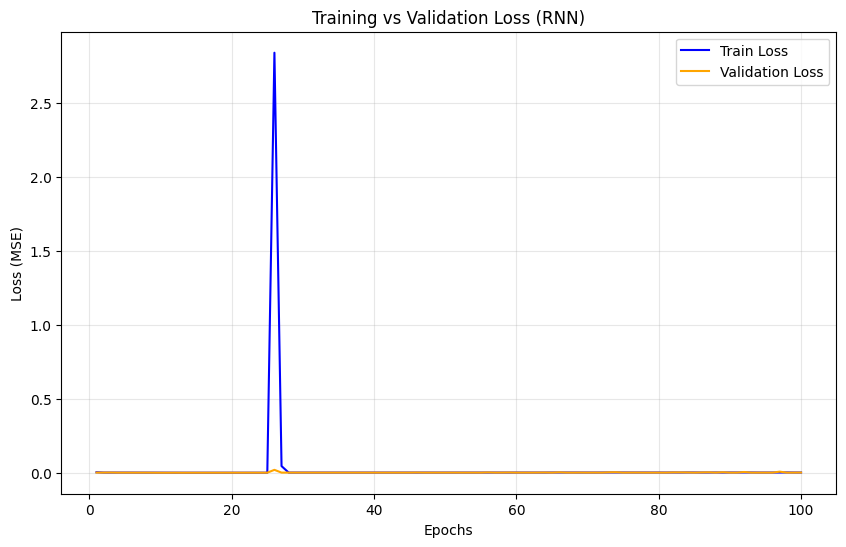

In [ ]:
# Assuming you have X_train_final, y_train_final, etc. from earlier
train_dataset = SequenceDataset(X_train_final, y_train_final)
val_dataset = SequenceDataset(X_val_final, y_val_final)
test_dataset = SequenceDataset(X_test_final, y_test_final)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Get input size dynamically from your data shape
num_features = X_train_final.shape[2]
rnn_model = StockRNN(input_size=num_features, output_size=1).to('cuda')

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

best_val_loss = float('inf')
epochs = 100

# Lists to keep track of losses for the graph
train_losses = []
val_losses = []

print(f"INIT TRAINING")

for t in range(epochs):
    # Capture both training and validation loss
    t_loss = train(train_loader, rnn_model, loss_fn, optimizer, 'cuda')
    v_loss = test(val_loader, rnn_model, loss_fn, 'cuda')

    # Store for plotting
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    print(f"Epoch {t+1}/{epochs}: Train Loss {t_loss:.6f} | Val Loss {v_loss:.6f}")

    # If best, save
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        print(f"*** New best model found! Val Loss: {v_loss:.6f}. Saving weights... ***")
        # Change the save name when doing RNN or GRU
        torch.save(rnn_model.state_dict(), 'best_stock_rnn.pth')

print("\nTraining Complete! Generating Loss Curve...")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='orange')

plt.title(f'Training vs Validation Loss (RNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Final Evaluation on Test Set ---
Final Test loss: 0.001149



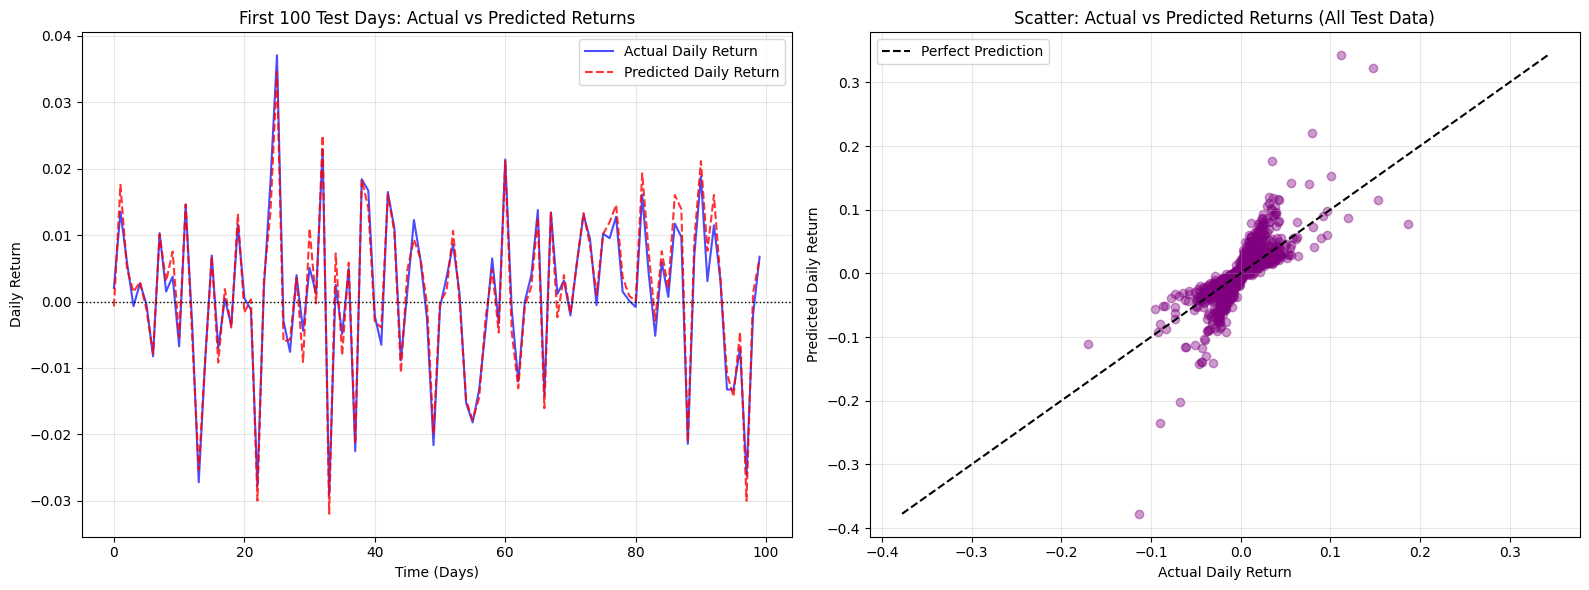

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load the best model
best_rnn = StockRNN(input_size=num_features, output_size=1)
best_rnn.load_state_dict(torch.load('best_stock_rnn.pth', weights_only=True))
best_rnn.to('cuda')

# Evaluate on the test set
print("--- Final Evaluation on Test Set ---")
test_loss = test(test_loader, best_rnn, loss_fn, 'cuda')
print(f"Final Test loss: {test_loss:.6f}\n")

# Put the best model in evaluation mode
best_rnn.eval()

all_preds = []
all_actuals = []

# 1. Gather all predictions from the test set using the best model
with torch.no_grad():
    for X, y in test_loader:
        X = X.to('cuda')

        preds = best_rnn(X).cpu().numpy()
        all_preds.extend(preds)
        all_actuals.extend(y.numpy())

# Ensure arrays are 2D for the scaler: (Samples, 1)
all_preds = np.array(all_preds).reshape(-1, 1)
all_actuals = np.array(all_actuals).reshape(-1, 1)

# 2. Inverse transform to get the true percentage returns
preds_unscaled = target_scaler.inverse_transform(all_preds)
actuals_unscaled = target_scaler.inverse_transform(all_actuals)

# 3. Create the visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Line Chart (First 100 Days) ---
slice_idx = 100
ax1.plot(actuals_unscaled[:slice_idx], label='Actual Daily Return', color='blue', alpha=0.7)
ax1.plot(preds_unscaled[:slice_idx], label='Predicted Daily Return', color='red', linestyle='--', alpha=0.8)
ax1.axhline(0, color='black', linewidth=1, linestyle=':') # Add a zero line
ax1.set_title("First 100 Test Days: Actual vs Predicted Returns")
ax1.set_xlabel("Time (Days)")
ax1.set_ylabel("Daily Return")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Scatter Plot (Overall Correlation) ---
ax2.scatter(actuals_unscaled, preds_unscaled, alpha=0.4, color='purple')

# Add a diagonal line representing "Perfect Predictions"
min_val = min(np.min(actuals_unscaled), np.min(preds_unscaled))
max_val = max(np.max(actuals_unscaled), np.max(preds_unscaled))
ax2.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction')

ax2.set_title("Scatter: Actual vs Predicted Returns (All Test Data)")
ax2.set_xlabel("Actual Daily Return")
ax2.set_ylabel("Predicted Daily Return")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 1 Summary

I used the RNN layer built in from PyTorch. I used a 512 dimension hidden state vector with the rest being default params. This RNN is single-layer (and operates on a sequence length of 14 as defined by my dataset). I then train a linear probe off this RNN to an output size of 1. There is no activation function between these layers or after the final layer. We are predicting daily return, which can be positive or negative. Furthermore, this percentage is unbounded. It could be +400% or -20%, etc. Regression. Thus, no activations are used. Furthermore, as this is regression, our evaluation metric will be MSE (mean squared error) which will also be our loss function.

A NOTE ON THE DATASET:
This dataset was the same that I used in a prior lab. I have already performed EDA on it in this lab. It is FAANG stock data. To avoid data leakages I made my train-validation-test split chronologically and per ticker. I selected the last 30% of data chronologically per ticker for the validation and test sets (first half being validation). I chose a context window of 14 days arbitrarily. Then, to make sequential data for training (and testing), I used a sliding window technique over the full track for that ticker, picking every length 14 section of data and marking the 15th day as the predicted target.

Our testing loss was 0.001149. Above you can see two visualizations of these results. The first one shows predicted daily return over the first 100 days in the testing data, where we slide the window and predict the following day for each. We follow the trend very well. The second graph shows predicted vs actual as a scatter plot. We see that our model trends towards picking a change of 0, with increasing variance in both directions of error (over and under prediction) fairly uniformly in each direction (actual being lower and actual being higher change over the day). When training, the best model had a validation MSE of 0.000580.

In [ ]:
class StockLSTM(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 512, batch_first=True)
        self.fc = nn.Linear(512, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        # Final FC operates on last seq item
        return self.fc(out[:, -1, :])

class StockGRU(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, 512, batch_first=True)
        self.fc = nn.Linear(512, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        # Final FC operates on last seq item
        return self.fc(out[:, -1, :])

INIT TRAINING
Epoch 1/100: Train Loss 0.005481 | Val Loss 0.001554
*** New best model found! Val Loss: 0.001554. Saving weights... ***
Epoch 2/100: Train Loss 0.001693 | Val Loss 0.001490
*** New best model found! Val Loss: 0.001490. Saving weights... ***
Epoch 3/100: Train Loss 0.001695 | Val Loss 0.001438
*** New best model found! Val Loss: 0.001438. Saving weights... ***
Epoch 4/100: Train Loss 0.001672 | Val Loss 0.001353
*** New best model found! Val Loss: 0.001353. Saving weights... ***
Epoch 5/100: Train Loss 0.001644 | Val Loss 0.001365
Epoch 6/100: Train Loss 0.001662 | Val Loss 0.001328
*** New best model found! Val Loss: 0.001328. Saving weights... ***
Epoch 7/100: Train Loss 0.001652 | Val Loss 0.001757
Epoch 8/100: Train Loss 0.001638 | Val Loss 0.001417
Epoch 9/100: Train Loss 0.001597 | Val Loss 0.001424
Epoch 10/100: Train Loss 0.001634 | Val Loss 0.001548
Epoch 11/100: Train Loss 0.001618 | Val Loss 0.001526
Epoch 12/100: Train Loss 0.001606 | Val Loss 0.001444
Epoch 1

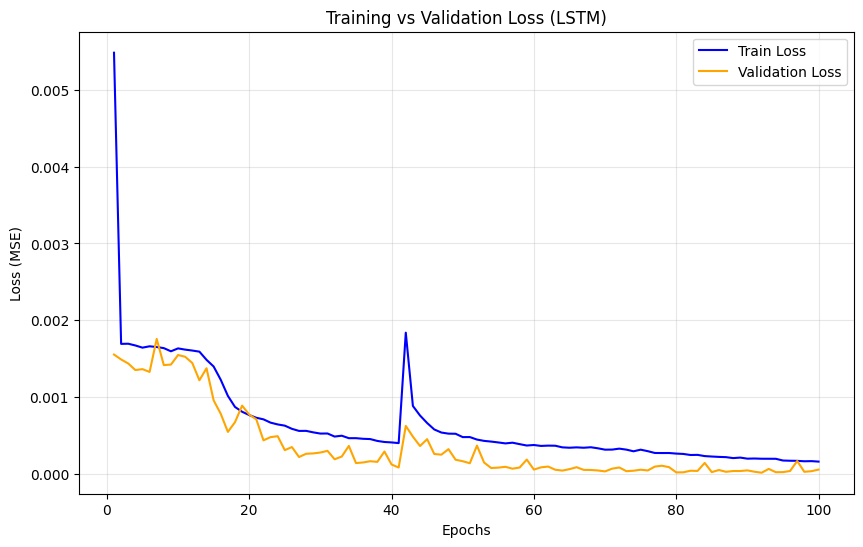

In [ ]:
# Get input size dynamically from your data shape
lstm_model = StockLSTM(input_size=num_features, output_size=1).to('cuda')

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

best_val_loss = float('inf')
epochs = 100

# Lists to keep track of losses for the graph
train_losses = []
val_losses = []

print(f"INIT TRAINING")

for t in range(epochs):
    # Capture both training and validation loss
    t_loss = train(train_loader, lstm_model, loss_fn, optimizer, 'cuda')
    v_loss = test(val_loader, lstm_model, loss_fn, 'cuda')

    # Store for plotting
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    print(f"Epoch {t+1}/{epochs}: Train Loss {t_loss:.6f} | Val Loss {v_loss:.6f}")

    # If best, save
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        print(f"*** New best model found! Val Loss: {v_loss:.6f}. Saving weights... ***")
        # Change the save name when doing RNN or GRU
        torch.save(lstm_model.state_dict(), 'best_stock_rnn.pth')

print("\nTraining Complete! Generating Loss Curve...")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='orange')

plt.title(f'Training vs Validation Loss (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Final Evaluation on Test Set ---
Final Test loss: 0.000084



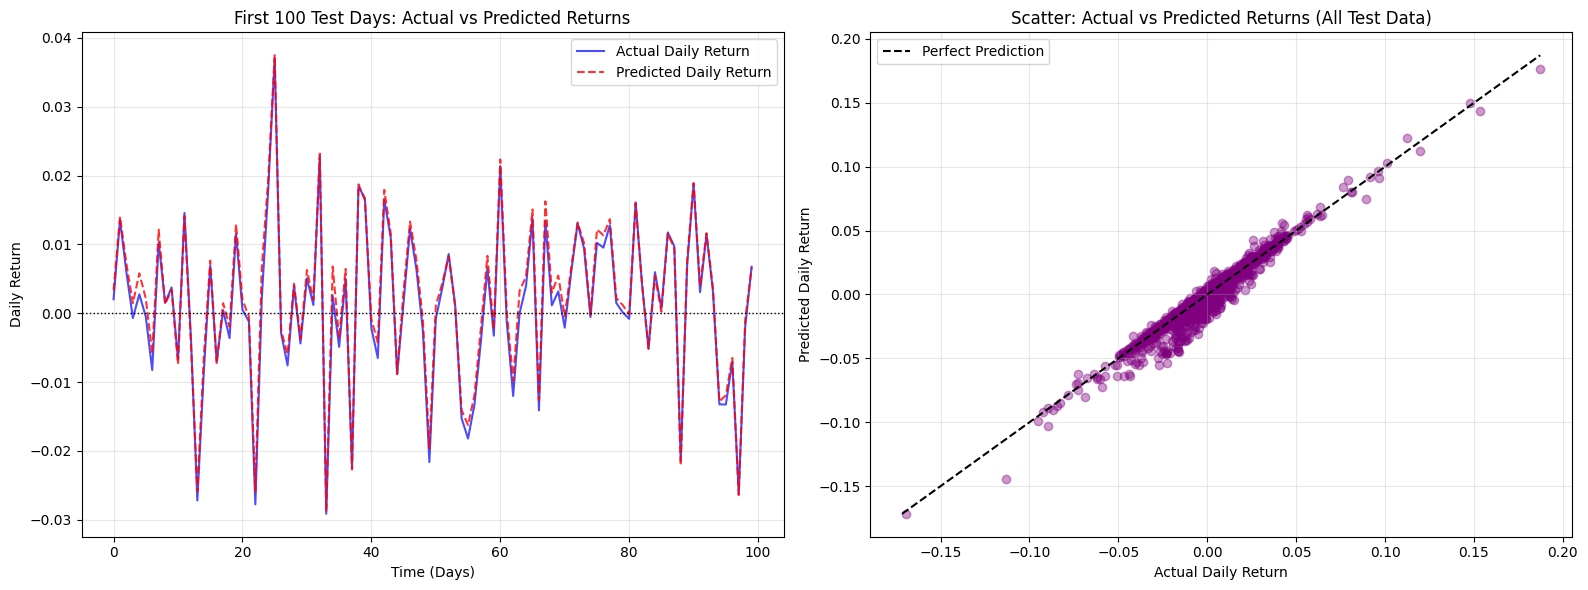

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load the best model
best_lstm = StockLSTM(input_size=num_features, output_size=1)
best_lstm.load_state_dict(torch.load('best_stock_lstm.pth', weights_only=True))
best_lstm.to('cuda')

# Evaluate on the test set
print("--- Final Evaluation on Test Set ---")
test_loss = test(test_loader, best_lstm, loss_fn, 'cuda')
print(f"Final Test loss: {test_loss:.6f}\n")

# Put the best model in evaluation mode
best_lstm.eval()

all_preds = []
all_actuals = []

# 1. Gather all predictions from the test set using the best model
with torch.no_grad():
    for X, y in test_loader:
        X = X.to('cuda')

        preds = best_lstm(X).cpu().numpy()
        all_preds.extend(preds)
        all_actuals.extend(y.numpy())

# Ensure arrays are 2D for the scaler: (Samples, 1)
all_preds = np.array(all_preds).reshape(-1, 1)
all_actuals = np.array(all_actuals).reshape(-1, 1)

# 2. Inverse transform to get the true percentage returns
preds_unscaled = target_scaler.inverse_transform(all_preds)
actuals_unscaled = target_scaler.inverse_transform(all_actuals)

# 3. Create the visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Line Chart (First 100 Days) ---
slice_idx = 100
ax1.plot(actuals_unscaled[:slice_idx], label='Actual Daily Return', color='blue', alpha=0.7)
ax1.plot(preds_unscaled[:slice_idx], label='Predicted Daily Return', color='red', linestyle='--', alpha=0.8)
ax1.axhline(0, color='black', linewidth=1, linestyle=':') # Add a zero line
ax1.set_title("First 100 Test Days: Actual vs Predicted Returns")
ax1.set_xlabel("Time (Days)")
ax1.set_ylabel("Daily Return")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Scatter Plot (Overall Correlation) ---
ax2.scatter(actuals_unscaled, preds_unscaled, alpha=0.4, color='purple')

# Add a diagonal line representing "Perfect Predictions"
min_val = min(np.min(actuals_unscaled), np.min(preds_unscaled))
max_val = max(np.max(actuals_unscaled), np.max(preds_unscaled))
ax2.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction')

ax2.set_title("Scatter: Actual vs Predicted Returns (All Test Data)")
ax2.set_xlabel("Actual Daily Return")
ax2.set_ylabel("Predicted Daily Return")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The LSTM model performed much better than the RNN model. This is most evident by the second graph, where we no longer see increasing variance in prediction as we move away from an actual zero-change day. Here, predicted daily return and actual daily return are much tighter along the perfect prediction line, on both ends. If anything, the graph suggests we underpredict daily return (more negative) than we overpredict. Looking at the first 100 days, we once again follow the true daily return very accurately. Our testing MSE was 0.000084 and validation MSE was 0.000017.

INIT TRAINING
Epoch 1/100: Train Loss 0.004343 | Val Loss 0.001565
*** New best model found! Val Loss: 0.001565. Saving weights... ***
Epoch 2/100: Train Loss 0.001698 | Val Loss 0.001425
*** New best model found! Val Loss: 0.001425. Saving weights... ***
Epoch 3/100: Train Loss 0.001643 | Val Loss 0.001331
*** New best model found! Val Loss: 0.001331. Saving weights... ***
Epoch 4/100: Train Loss 0.001657 | Val Loss 0.001302
*** New best model found! Val Loss: 0.001302. Saving weights... ***
Epoch 5/100: Train Loss 0.001590 | Val Loss 0.001323
Epoch 6/100: Train Loss 0.001576 | Val Loss 0.001618
Epoch 7/100: Train Loss 0.001579 | Val Loss 0.001184
*** New best model found! Val Loss: 0.001184. Saving weights... ***
Epoch 8/100: Train Loss 0.001508 | Val Loss 0.001115
*** New best model found! Val Loss: 0.001115. Saving weights... ***
Epoch 9/100: Train Loss 0.001439 | Val Loss 0.001054
*** New best model found! Val Loss: 0.001054. Saving weights... ***
Epoch 10/100: Train Loss 0.001421

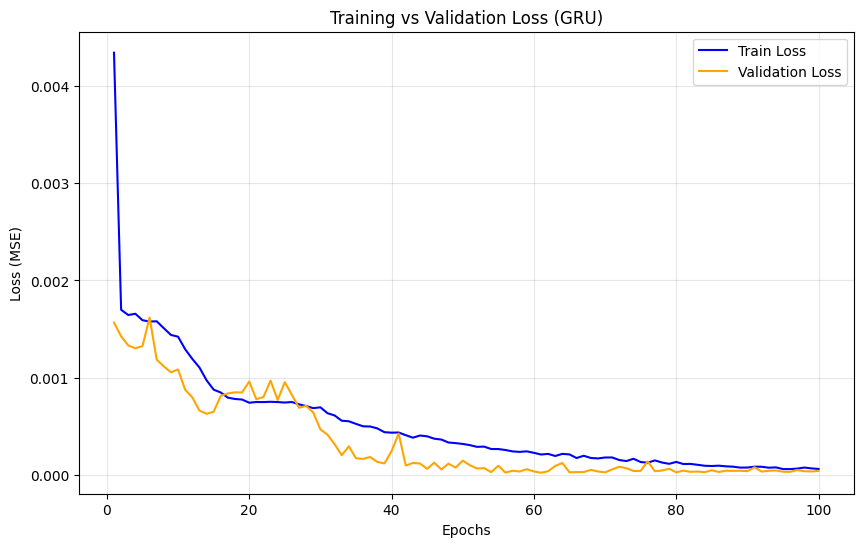

In [ ]:
# Get input size dynamically from your data shape
gru_model = StockGRU(input_size=num_features, output_size=1).to('cuda')

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

best_val_loss = float('inf')
epochs = 100

# Lists to keep track of losses for the graph
train_losses = []
val_losses = []

print(f"INIT TRAINING")

for t in range(epochs):
    # Capture both training and validation loss
    t_loss = train(train_loader, gru_model, loss_fn, optimizer, 'cuda')
    v_loss = test(val_loader, gru_model, loss_fn, 'cuda')

    # Store for plotting
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    print(f"Epoch {t+1}/{epochs}: Train Loss {t_loss:.6f} | Val Loss {v_loss:.6f}")

    # If best, save
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        print(f"*** New best model found! Val Loss: {v_loss:.6f}. Saving weights... ***")
        # Change the save name when doing RNN or GRU
        torch.save(gru_model.state_dict(), 'best_stock_rnn.pth')

print("\nTraining Complete! Generating Loss Curve...")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='orange')

plt.title(f'Training vs Validation Loss (GRU)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Final Evaluation on Test Set ---
Final Test loss: 0.000354



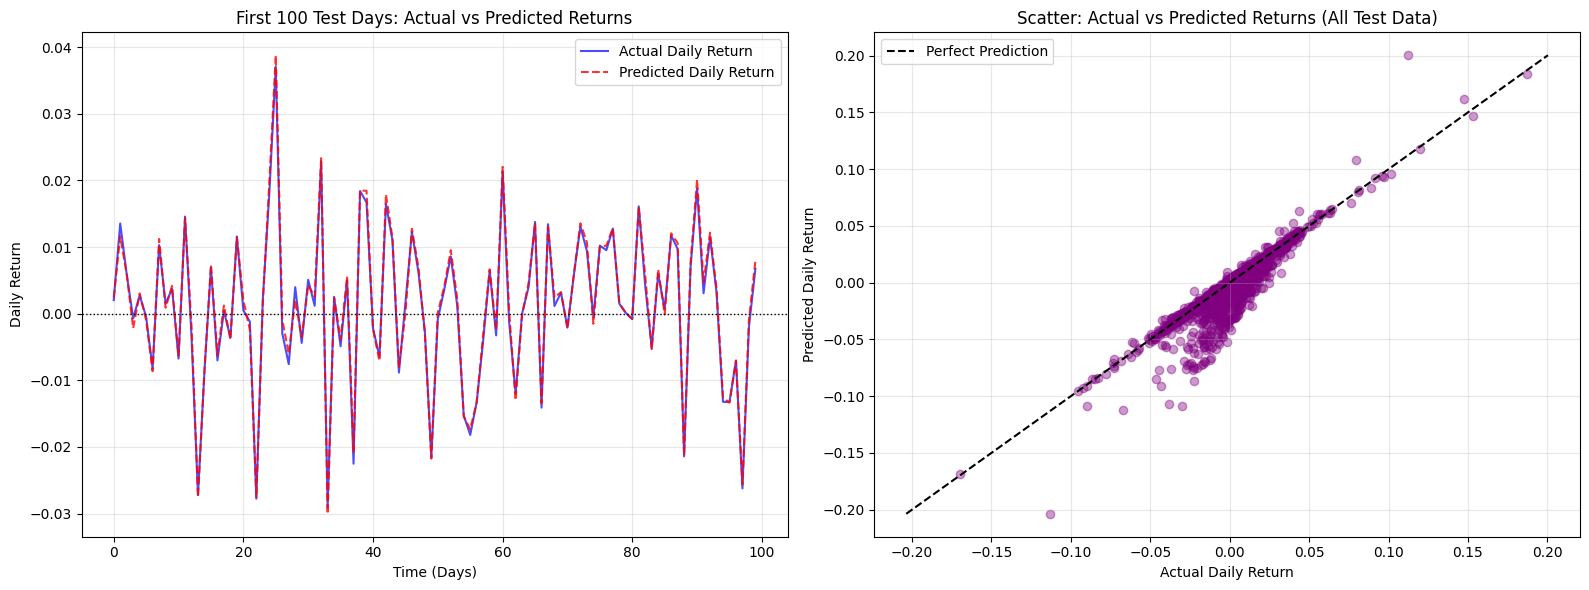

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load the best model
best_gru = StockGRU(input_size=num_features, output_size=1)
best_gru.load_state_dict(torch.load('best_stock_gru.pth', weights_only=True))
best_gru.to('cuda')

# Evaluate on the test set
print("--- Final Evaluation on Test Set ---")
test_loss = test(test_loader, best_gru, loss_fn, 'cuda')
print(f"Final Test loss: {test_loss:.6f}\n")

# Put the best model in evaluation mode
best_gru.eval()

all_preds = []
all_actuals = []

# 1. Gather all predictions from the test set using the best model
with torch.no_grad():
    for X, y in test_loader:
        X = X.to('cuda')

        preds = best_gru(X).cpu().numpy()
        all_preds.extend(preds)
        all_actuals.extend(y.numpy())

# Ensure arrays are 2D for the scaler: (Samples, 1)
all_preds = np.array(all_preds).reshape(-1, 1)
all_actuals = np.array(all_actuals).reshape(-1, 1)

# 2. Inverse transform to get the true percentage returns
preds_unscaled = target_scaler.inverse_transform(all_preds)
actuals_unscaled = target_scaler.inverse_transform(all_actuals)

# 3. Create the visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Line Chart (First 100 Days) ---
slice_idx = 100
ax1.plot(actuals_unscaled[:slice_idx], label='Actual Daily Return', color='blue', alpha=0.7)
ax1.plot(preds_unscaled[:slice_idx], label='Predicted Daily Return', color='red', linestyle='--', alpha=0.8)
ax1.axhline(0, color='black', linewidth=1, linestyle=':') # Add a zero line
ax1.set_title("First 100 Test Days: Actual vs Predicted Returns")
ax1.set_xlabel("Time (Days)")
ax1.set_ylabel("Daily Return")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Scatter Plot (Overall Correlation) ---
ax2.scatter(actuals_unscaled, preds_unscaled, alpha=0.4, color='purple')

# Add a diagonal line representing "Perfect Predictions"
min_val = min(np.min(actuals_unscaled), np.min(preds_unscaled))
max_val = max(np.max(actuals_unscaled), np.max(preds_unscaled))
ax2.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction')

ax2.set_title("Scatter: Actual vs Predicted Returns (All Test Data)")
ax2.set_xlabel("Actual Daily Return")
ax2.set_ylabel("Predicted Daily Return")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

GRU also performed better than RNN with a test loss of 0.000354 and validation loss of 0.000021. Interestingly, GRU performed worse than LSTM but exaggerated the error trend that LSTM had. Clearly seen in the scatter plot, GRU is often underpredicting daily return rates, especially when the actual daily return is close to zero or slightly negative. It almost never overpredicts, but often underpredicts. The first 100 days graph looks almost perfect.

Comparing the three models, LSTM > GRU > RNN in performance (LSTM BEST). A good explanation for why RNNs do the worst is the vanishing gradient issue, in a sense that their sequential knowledge dilutes over time. While the sequence length is 14, it can't reasonably learn complex relationships back 14 days because gradients shrink by the time we hit the end of that context window. LSTM doesn't have this problem and thus can learn broader context better, hence the better predictions. GRU merges cell and hideen states, so short-term behavior bleeds into the cell state. Thus, while it does better at observing the full context window than RNNs, it incorporates some form of recency bias.

### Part 3

You could use a feed-forward network to solve the same problem. If we have a context window of 14 days, can't we just flatten that into 14 times N (N features per day) feature vectors? We then train off this data. We persist all data, but we now lack time information for each day. The network doesn't clearly know which day occurs when. Furthermore, our dimensionality has now skyrocketed, so overfitting is a concern.